In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(ggrepel))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

tmp_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#9C4F43', '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')
names(clust_hexes) <- tmp_order

mod_order <- c('RNA', 'ATAC')
mod_hexes <- c('#48B028', '#51ADCF')

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### B: Fail1-specific immune genes

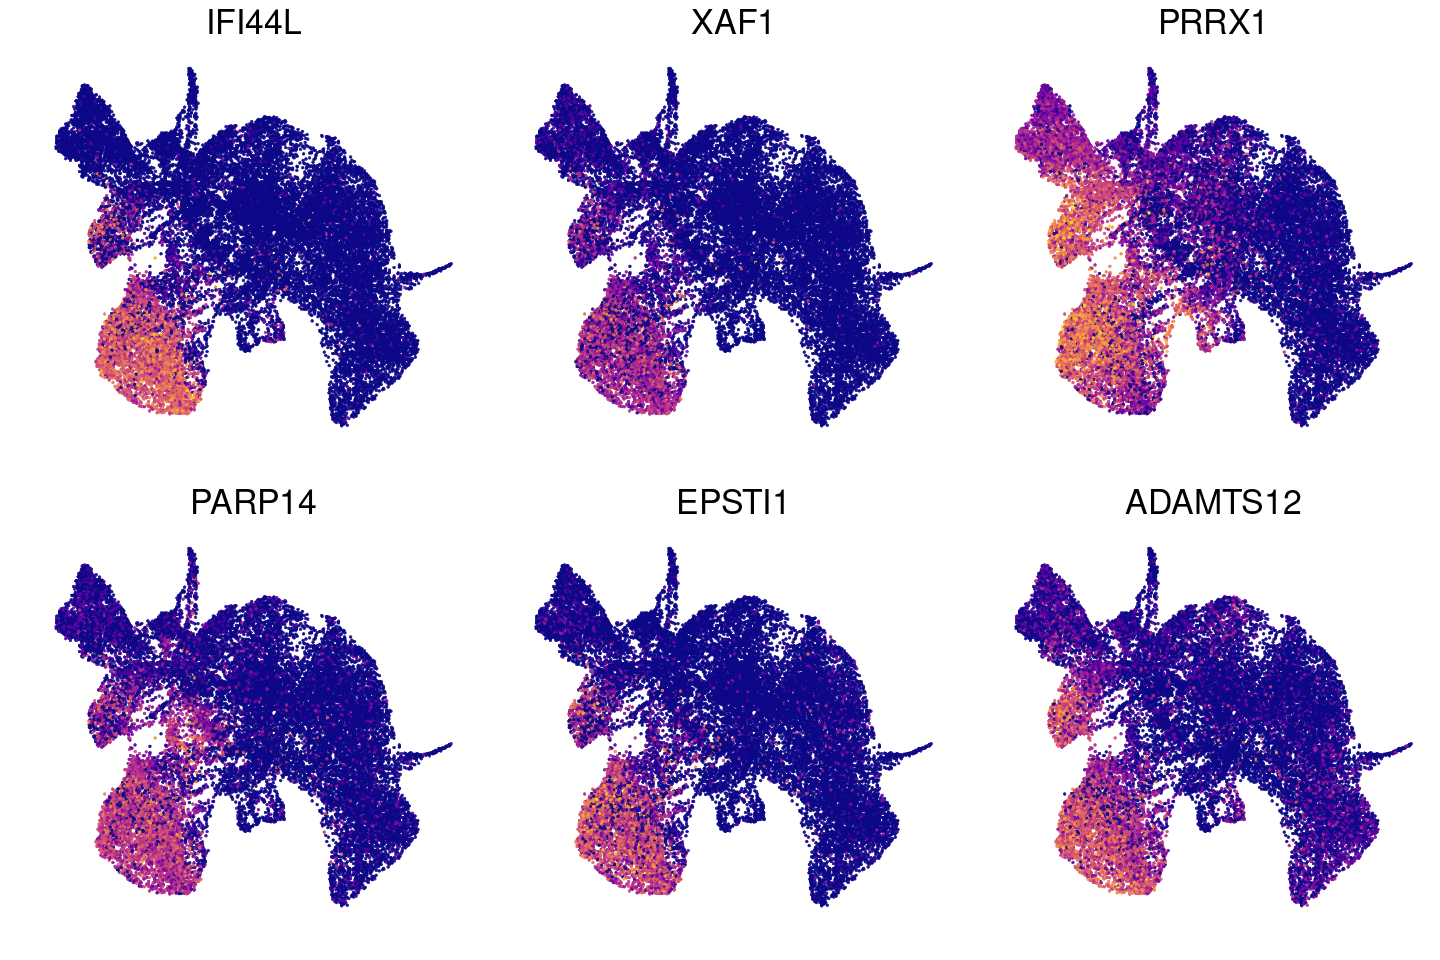

In [ ]:
rna_umap_path = paste0(projdir, '/csv/figure3/multiome_rna_immune_fail.csv')
rna_umap = as.data.frame(fread(rna_umap_path, sep='\t'))
rna_umap$coarse <- factor(rna_umap$coarse, levels=tmp_order)

set.seed(1)
shuffled_rna_umap <- rna_umap[sample(nrow(rna_umap)), ]

genes <- colnames(rna_umap)[6:11]
genes

plot_umap <- function(tmp_df, g) {
  ggplot(shuffled_rna_umap, aes_string(x = "umap0", y = "umap1", color = g)) +
        geom_point_rast(alpha=0.8, size=0.1) +
      labs(x = "", y = "", title=g) +
      theme_bw() +
      base_theme +
        theme(
            axis.text.x = element_blank(),
            axis.text.y = element_blank(),
        plot.title  = element_text(size=20, color='black', hjust=0.5)) +
        scale_color_viridis_c(option = "plasma") +
            guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))
}

plot_list <- list()

for (i in seq_along(genes)) {
    g <- genes[i]
    plot_list[[i]] <- plot_umap(shuffled_rna_umap, g)
}

w = 12
h = 8
options(repr.plot.width=w, repr.plot.height=h)
combined_plot <- plot_grid(plotlist = plot_list, ncol=3, nrow=2)
combined_plot

### C: OSKM expression

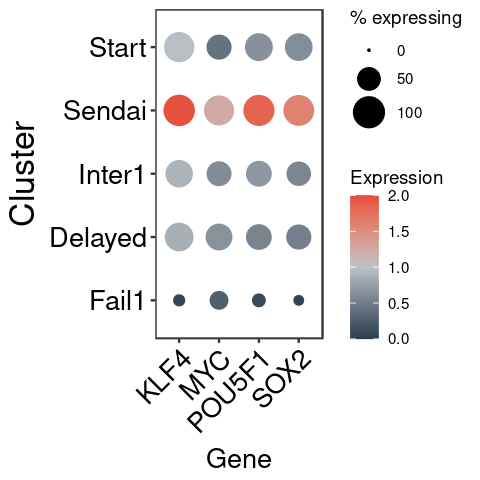

In [ ]:
fail1_order <- rev(c('Start', 'Sendai', 'Inter1', 'Delayed', 'Fail1'))

oskm_path = paste0(projdir, '/csv/figure3/multiome_rna_oskm_fail.csv')
oskm = as.data.frame(fread(oskm_path, sep='\t'))
oskm$coarse <- factor(oskm$coarse, levels=fail1_order)

dot_df <- oskm %>%
  group_by(coarse, variable) %>%
  summarise(
    avg_expr = mean(value),
    pct_expr = mean(value > 0) * 100,
    .groups = "drop"
  )

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(dot_df, aes(x = variable, y = coarse)) +
  geom_point(aes(size = pct_expr, color = avg_expr)) +

  labs(x='Gene', y='Cluster', size = "% expressing", color = "Expression") +
  scale_color_gradientn(colors = c("#2c3e50", "#bdc3c7", "#e74c3c"), limits = c(0, 2)) +
  scale_size_area(max_size = 8, breaks = c(0, 50, 100), limits = c(0, 100)) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size=16, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

### D: OSKM TF footprinting

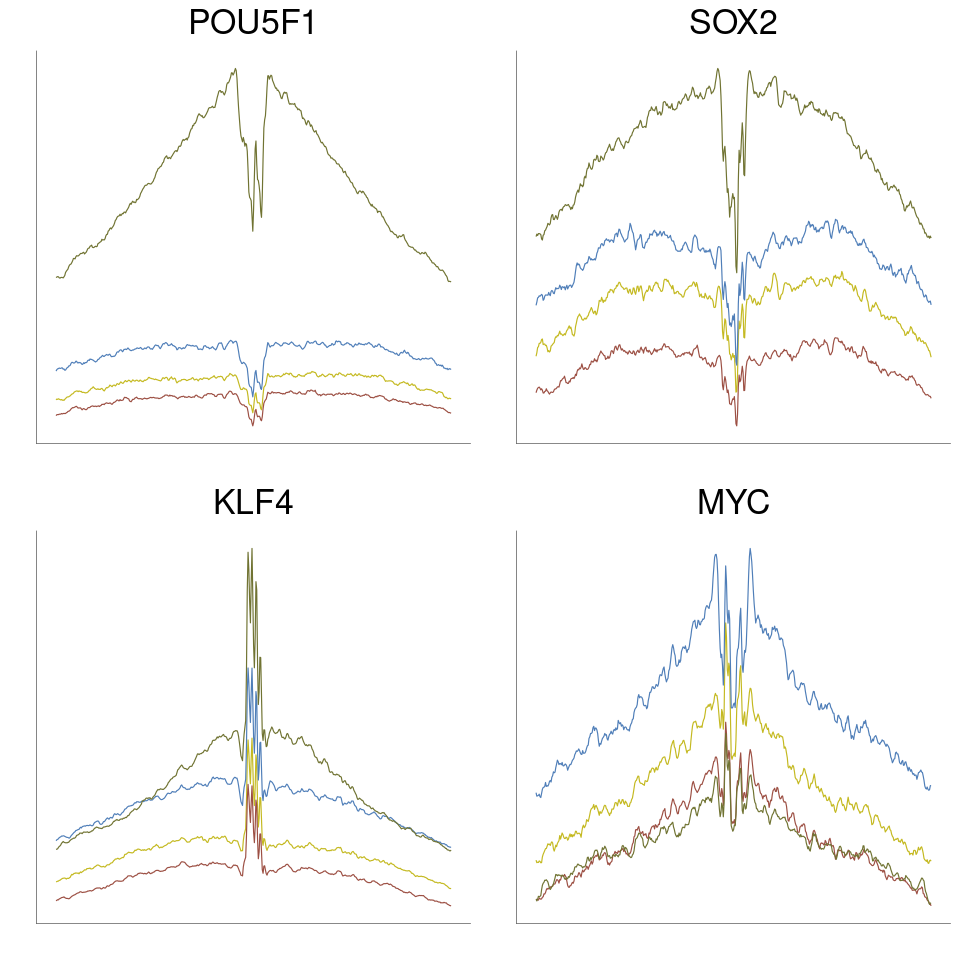

In [ ]:
footprint_path = paste0(projdir, '/csv/figure3/atac_oskm_footprint.csv')
footprint = as.data.frame(fread(footprint_path, sep='\t'))
footprint_order <- c('Start', 'Delayed', 'Fail1', 'Sendai')
mask <- footprint$cluster %in% footprint_order
footprint <- footprint[mask,]
footprint$cluster <- factor(footprint$cluster, levels=footprint_order)

tfs <- unique(footprint$TF)
tfs

plot_footprint <- function(footprint, tf) {
 tmp_footprint <- footprint[footprint$TF == tf,]
ggplot(tmp_footprint, aes(x = variable, y = value_smooth, color = cluster)) +
    geom_line(linewidth=0.25) +
  labs(x = "", y = "", color='', title=tf) +
  theme_bw() +
  base_theme +
    theme(
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
        axis.line = element_line(linewidth=0.1),
        plot.title = element_text(size=20, color='black', hjust=0.5),
    legend.position = 'none') +
    scale_color_manual(values=clust_hexes)
}

plot_list <- list()

for (i in seq_along(tfs)) {
    tf <- tfs[i]
    plot_list[[i]] <- plot_footprint(footprint, tf)
}

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)

combined_plot <- plot_grid(plotlist = plot_list, ncol=2, nrow=2)
combined_plot

### E: Fail2 and early-IPS marker genes

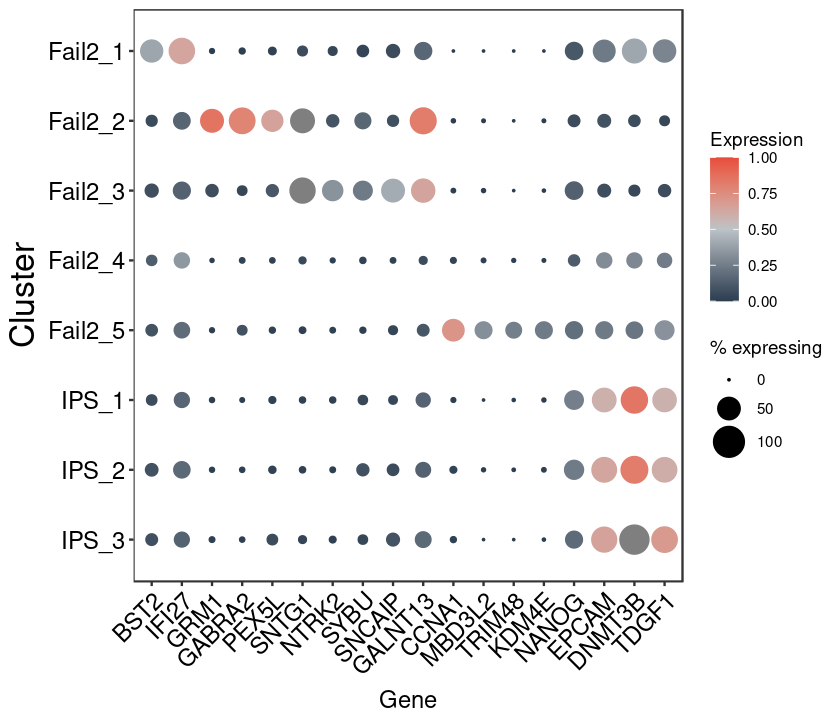

In [ ]:
expr_path = paste0(projdir, '/csv/figure3/multiome_rna_fail2_dot_plot.csv')
expr = as.data.frame(fread(expr_path, sep='\t'))

dot_df <- expr %>%
  group_by(cluster, variable) %>%
  summarise(
    avg_expr = mean(value),
    pct_expr = mean(value > 0) * 100,
    .groups = "drop"
  )

fail2_order <- rev(c("Fail2_1", "Fail2_2", "Fail2_3", "Fail2_4", "Fail2_5",
                 "IPS_1", "IPS_2", "IPS_3"))

gene_order <- c('BST2', 'IFI27',
                'GRM1', 'GABRA2', 'PEX5L', 'SNTG1',
                'NTRK2', 'SYBU', 'SNCAIP', 'GALNT13',
                 'CCNA1', 'MBD3L2', 'TRIM48', 'KDM4E',
                'NANOG', 'EPCAM', 'DNMT3B', 'TDGF1')

whitelist <- c('Fail2', 'IPS')
tmp_rownames <- sub('*_.', '', dot_df$cluster)
mask <- tmp_rownames %in% whitelist
final_dot <- dot_df[mask,]
final_dot$cluster <- factor(final_dot$cluster, levels=fail2_order)

final_dot$variable <- factor(final_dot$variable, levels=gene_order)

w = 7
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ggplot(final_dot, aes(x = variable, y = cluster)) +
  geom_point(aes(size = pct_expr, color = avg_expr)) +

  labs(x='Gene', y='Cluster', size = "% expressing", color = "Expression") +
  scale_color_gradientn(colors = c("#2c3e50", "#bdc3c7", "#e74c3c"), limits = c(0, 1)) +
  scale_size_area(max_size = 8, breaks = c(0, 50, 100), limits = c(0, 100)) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size=14, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_text(size=14, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=14, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

### G: SCENIC+ regulon AUC, Start vs. Fail1

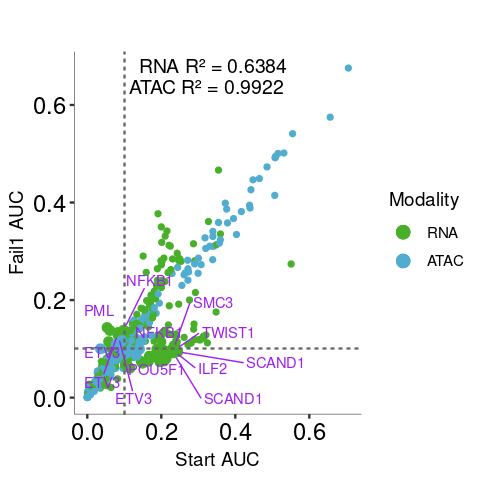

In [ ]:
merged_auc_path = paste0(projdir, '/csv/figure3/scenic_pseudo_auc.csv')
merged_auc = as.data.frame(fread(merged_auc_path, sep='\t'))
merged_auc$mod <- factor(merged_auc$mod, levels=mod_order)
merged_auc$regulon <- sub("_.*", "", merged_auc$V1)

shuffled_merged_auc <- merged_auc[sample(nrow(merged_auc)), ]

start_highlight <- merged_auc %>% filter(start_AUC > 0.1, fail1_AUC < 0.1)
fail1_highlight <- merged_auc %>% filter(start_AUC < 0.1, fail1_AUC > 0.1)

start_label <- start_highlight %>%
  arrange(desc(start_AUC)) %>%
  slice_head(n = 6)

fail1_label <- fail1_highlight %>%
  arrange(desc(fail1_AUC)) %>%
  slice_head(n = 6)

labels_df <- bind_rows(start_label, fail1_label)

rna_anno <- annotate(
  "text",
  x = Inf, y = Inf,
  label = "RNA R² = 0.6384",
  hjust = 1.5,
  vjust = 1.5,
  size = 4
)

atac_anno <- annotate(
  "text",
  x = Inf, y = Inf,
  label = "ATAC R² = 0.9922",
  hjust = 1.5,
  vjust = 3,
  size = 4
)

w = 4
h = 4
options(repr.plot.width = w, repr.plot.height = h)

ggplot(shuffled_merged_auc, aes(x = start_AUC, y = fail1_AUC, color = mod)) +
    geom_point(size = 1) +
    rna_anno +
    atac_anno +
    geom_point(data=start_highlight, size = 2) +
    geom_point(data=fail1_highlight, size = 2) +
    geom_text_repel(data = labels_df, aes(label = regulon), size = 3, color = "purple",
                   max.overlaps = Inf, box.padding = 0.4, point.padding = 0.3, segment.size = 0.3) +
    geom_hline(yintercept = 0.1, linetype = "dashed", color = "grey40") +
    geom_vline(xintercept = 0.1, linetype = "dashed", color = "grey40") +
    labs(x = "Start AUC", y = "Fail1 AUC", color = 'Modality', title = '') +
    theme_bw() +
    base_theme +
  theme(
    axis.text.x = element_text(size = 14, color = 'black'),
    axis.text.y = element_text(size = 14, color = 'black'),
    axis.line = element_line(linewidth = 0.1),
    axis.ticks.x = element_line(),
    axis.ticks.y = element_line(),
    plot.title = element_text(size = 20, color = 'black', hjust = 0.5),
    legend.position = 'right'
  ) +
  scale_color_manual(values = mod_hexes) +
          guides(color = guide_legend(override.aes = list(size = 3)),
            shape = guide_legend(title = ''))

### H: regulon AUC difference, Start vs. Fail1

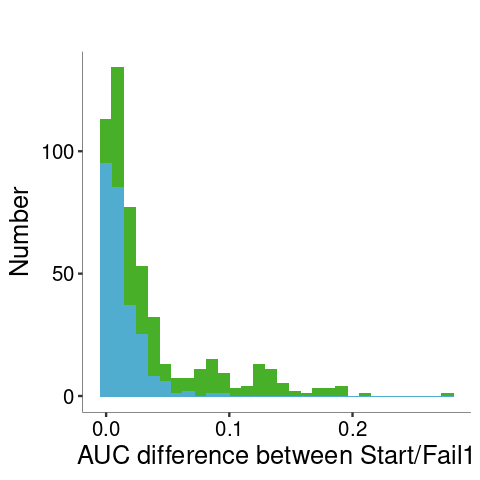

In [ ]:
tmp_rna <- merged_auc[merged_auc$mod == 'RNA',]
tmp_atac <- merged_auc[merged_auc$mod == 'ATAC',]
tmp_rna$diff <- abs(tmp_rna$start_AUC - tmp_rna$fail1_AUC)
tmp_atac$diff <- abs(tmp_atac$start_AUC - tmp_atac$fail1_AUC)

auc_diff <- bind_rows(tmp_rna, tmp_atac)
auc_diff$mod <- factor(auc_diff$mod, levels=mod_order)

w = 4
h = 4
options(repr.plot.width = w, repr.plot.height = h)

ggplot(auc_diff, aes(x = diff, fill = mod)) +
    geom_histogram() +
    labs(x = "AUC difference between Start/Fail1", y = "Number", color = 'Modality', title = '') +
    theme_bw() +
    base_theme +
  theme(
    axis.text.x = element_text(size = 12, color = 'black'),
    axis.text.y = element_text(size = 12, color = 'black'),
    axis.title.x = element_text(size = 15, color = 'black'),
    axis.title.y = element_text(size = 15, color = 'black'),
    axis.ticks.x = element_line(),
    axis.ticks.y = element_line(),
    axis.line = element_line(linewidth = 0.1),
    plot.title = element_text(size = 20, color = 'black', hjust = 0.5),
    legend.position = 'none'
  ) +
  scale_fill_manual(values = mod_hexes)

### J: motif enrichment of Start/Fail1 differential peaks

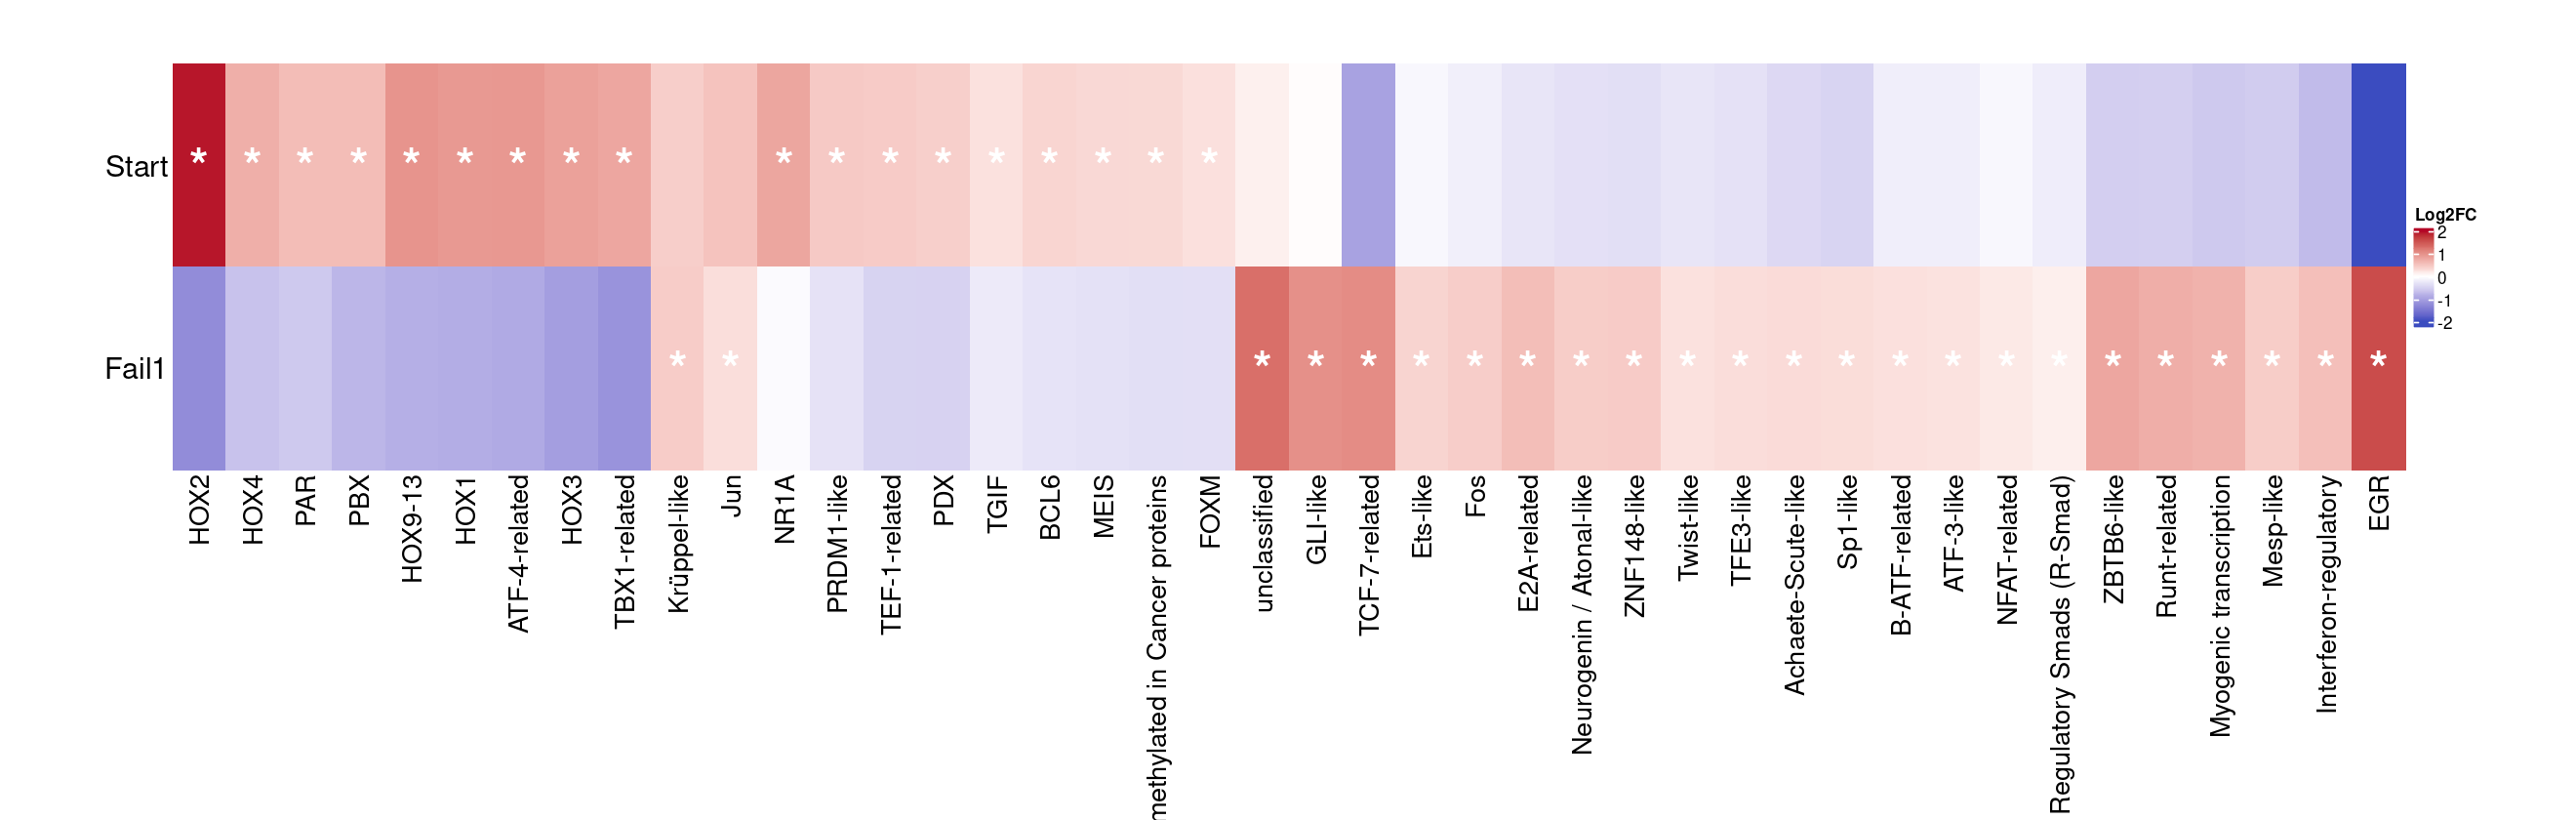

In [ ]:
motifs_path = paste0(projdir, '/csv/figure3/start_fail1_homer_fc.csv')
motifs = as.data.frame(fread(motifs_path, sep='\t'))
rownames(motifs) <- motifs$V1
motifs <- motifs[,-1]

fdr_path = paste0(projdir, '/csv/figure3/start_fail1_homer_pvals.csv')
fdr = as.data.frame(fread(fdr_path, sep='\t'))
rownames(fdr) <- fdr$V1
fdr <- fdr[,-1]

thresh = 1e-5
tmp_fun <- function(j, i, x, y, w, h, fill) {
    if(!is.na(fdr_ordered[i, j]) && fdr_ordered[i, j] < thresh) {
        grid.text("*", x, y, gp = gpar(col = "white", fontsize = 30, fontface = "bold"))
    }
}

ht_tmp <- Heatmap(motifs,
              cluster_rows = TRUE,
              cluster_columns = TRUE)
row_ord <- row_order(ht_tmp)
col_ord <- column_order(ht_tmp)
fdr_ordered <- fdr[row_ord, col_ord]

motifs_ordered <- motifs[row_ord, col_ord]

ht <- Heatmap(motifs_ordered,
        name = "Log2FC",
        col = colorRamp2(c(-2, 0, 2), c("#3B4CC0", "white", "#B40426")),
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        cell_fun = tmp_fun,
        show_row_names = TRUE,
        show_column_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 18),
        column_names_gp = gpar(fontsize = 16, rot = 90),
        heatmap_width = unit(50, "cm"),
        heatmap_height = unit(15, "cm"))

ht

### K: differential peaks per Fail2 subcluster

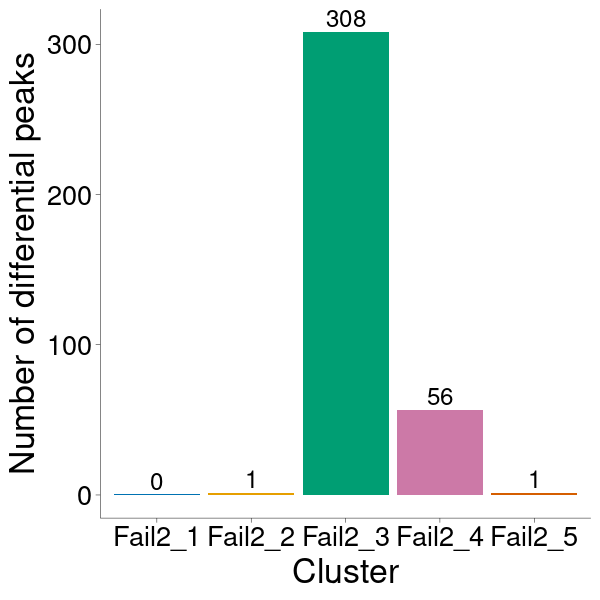

In [ ]:
fail2_hexes <- c('#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00')
names(fail2_hexes) <- paste0('Fail2_', 1:5)

fail2_diff_peaks_path = paste0(projdir, '/csv/figure3/fail2_diff_peak_dist.csv')
fail2_diff_peaks = as.data.frame(fread(fail2_diff_peaks_path, sep='\t'))
fail2_diff_peaks$cluster <- factor(fail2_diff_peaks$cluster, levels=names(fail2_hexes))

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(fail2_diff_peaks, aes(x = cluster, y = diff_peaks, fill=cluster)) +
  geom_bar(stat='identity', position='dodge') +
  geom_text(aes(label = diff_peaks), vjust = -0.3, size = 5) +
  labs(x = "Cluster", y = "Number of differential peaks", fill = "Cluster") +
  theme_bw() +
  base_theme +
  theme(
    axis.text = element_text(size=16, color='black'),
    axis.title = element_text(size=20, color='black'),
    axis.line = element_line(linewidth=0.10),
    axis.ticks.x = element_line(linewidth=0.10),
    axis.ticks.y = element_line(linewidth=0.10),

    axis.ticks = element_blank()) +
  scale_fill_manual(values = fail2_hexes)

### L: chromVAR deviation scores, Fail2 and productive branches

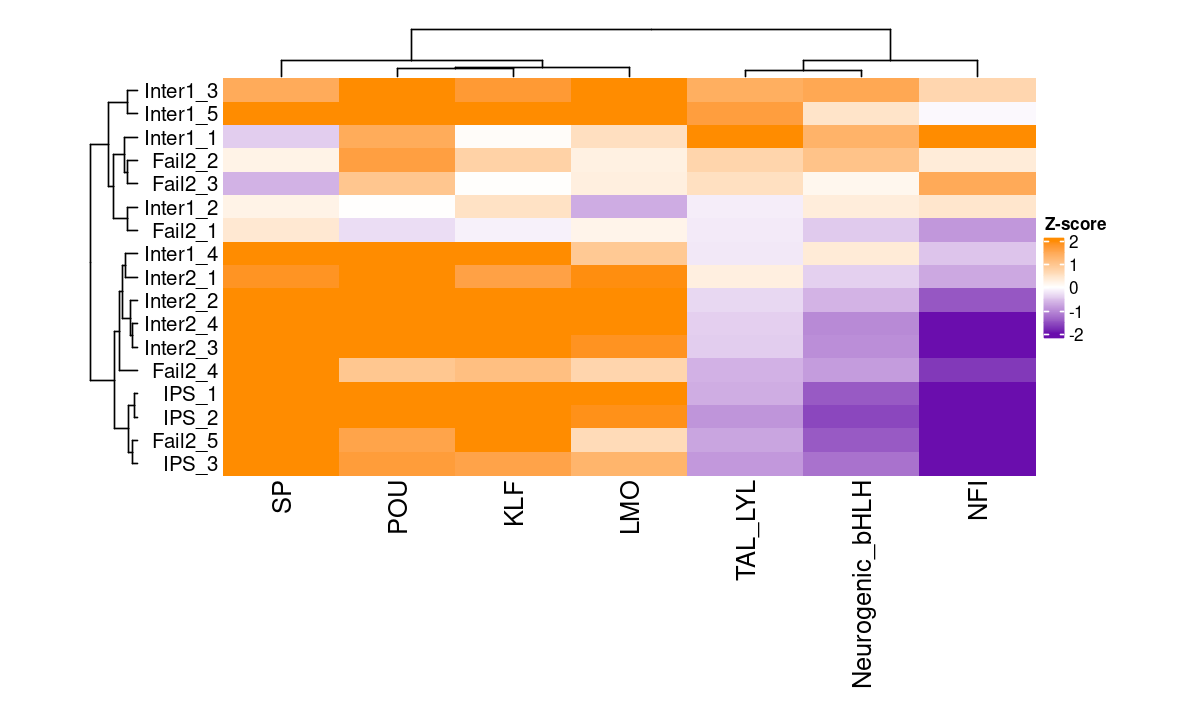

In [ ]:
chromvar_path = paste0(projdir, '/csv/figure3/atac_chromvar_cluster_deviation_subfamily.csv')
chromvar = as.data.frame(fread(chromvar_path, sep='\t'))
rownames(chromvar) <- chromvar$V1
chromvar <- chromvar[,-1]

whitelist = c('Inter1', 'Inter2', 'Fail2', 'IPS')
tmp_rownames <- sub('*_.', '', rownames(chromvar))
mask <- tmp_rownames %in% whitelist
tmp_chromvar <- chromvar[mask,]

col_fun <- colorRamp2(c(-2, 0, 2), c("#6A0DAD", "white", "#FF8C00"))

sel <- c('SP', 'POU', 'KLF', 'LMO', 'TAL_LYL', 'Neurogenic_bHLH', 'NFI')
mask <- colnames(tmp_chromvar) %in% sel
final_chromvar <- tmp_chromvar[,mask]

w = 10
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ht <- Heatmap(final_chromvar,
        name = "Z-score",
        col = col_fun,
        cluster_rows = TRUE,
        cluster_columns = TRUE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 12),
        column_names_gp = gpar(fontsize = 15, rot = 90),
        heatmap_width = unit(20, "cm"),
        heatmap_height = unit(14, "cm"))

ht

In [ ]:
sessionInfo()

In [ ]:
Sys.time()